# **Problem Set - Performance-Seeking Portfolios**

Note : dans tout le document, on ne distinguera pas la notation des scalaires et des vecteurs, sauf dans les cas où cela pourrait créer une ambiguïté. On note $e$ le vecteur unitaire $w$ le vecteur des poids, $\Sigma$ la matrice de covariance. On note également $\sigma$ la volatilité ou le vecteur des volatilité et $\mu$ le rendement ou le vecteur des rendements, accompagnés d'indices si besoin.

## **Exercice 1**

Sous sa forme générique, la matrice de covariance pour deux actifs est donnée par : $ \Sigma = \begin{pmatrix}
\sigma_1^2 & \sigma_{1, 2} \\
\sigma_{2, 1} & \sigma_2^2
\end{pmatrix} $

Ici, les deux actifs 1 et 2 sont décorrélés, donc :  $ \sigma_{1, 2} = \sigma_{2, 1} = 0 $, c'est-à-dire : 
$ \Sigma = \begin{pmatrix}
\sigma_1^2 & 0 \\
0 & \sigma_2^2
\end{pmatrix} $

Le portefeuille GMV correspond aux poids $w$ définis tels que : 
$$ \min_{w} w' \Sigma w $$ s.c. $ e'w = 1$, soit ici : $ w_1 = w $ et $  w_2 = 1 - w $. 

Notons que $ w' \Sigma w $ correspondent à la volatilité $ \sigma_{GMV} $ du portfolio GMV.

On a :

$$
\sigma_{\mathrm{GMV}}(w)^2 =
\begin{pmatrix}
w & 1-w
\end{pmatrix}
\begin{pmatrix}
\sigma_1^2 & 0 \\
0 & \sigma_2^2
\end{pmatrix}
\begin{pmatrix}
w \\
1-w
\end{pmatrix}
= \sigma_1^2 w^2 + \sigma_2^2 (1-w)^2
$$

La fonction est quadratique, on peut trouver le minimum au point d'annulation de la dérivée :

$$ \frac{d \sigma_{GMV}^2}{dw} = 2w \cdot (\sigma_1^2 + \sigma_2^2) - 2\sigma_2^2 = 0 $$

On obtient donc bien : $ \boxed{ w = \frac{\sigma_2^2}{\sigma_1^2 + \sigma_2^2} = \frac{\sigma_1^{-2}}{\sigma_1^{-2} + \sigma_2^{-2}}} $ puis $1-w = \frac{\sigma_2^{-2}}{\sigma_1^{-2} + \sigma_2^{-2}} $



## **Exercice 2**

1. A l'aide de la définition de la covariance $ \sigma_{i, j} = \sigma_i \sigma_j \rho_{i, j} $, on calcule :
$$ \Sigma = \begin{pmatrix}
0,04 & 0,018 & -0,004 \\
0,018 & 0,0225 & -0,0015 \\
-0,004 & -0,0015 & 0,01
\end{pmatrix} $$

2. Par définition du portfolio équipondéré : $w_1 = w_2 = w_3 = \frac{1}{3} $. On a ainsi :

- $\mu_{EW} = w' \mu = \frac{1}{3} \cdot 0,1 + \frac{1}{3} \cdot 0,08 + \frac{1}{3} \cdot 0,06 = 0,08 $ soit $\boxed{\mu_{EW} = 8\%}$
  
- $ \sigma_{EW}^2 = w' \Sigma w = \begin{pmatrix} \frac{1}{3} & \frac{1}{3} & \frac{1}{3} \end{pmatrix} \begin{pmatrix} 0,04 & 0,018 & -0,004 \\ 0,018 & 0,0225 & -0,0015 \\-0,004 & -0,0015 & 0,01 \end{pmatrix} \begin{pmatrix} \frac{1}{3} \\ \frac{1}{3} \\\frac{1}{3} \end{pmatrix} \approx 0,010833 $

d'où la volatilité : $ \boxed{\sigma_{EW} \approx 10,4\%}$

3. Le vecteur des poids est ici donné par $ w = \begin{pmatrix} 14/31 \\ 10/12 \\ -53/186 \end{pmatrix} $. Notons que le poids négatif correspond à une position courte sur l'actif 3. Similairement qu'à la question 2, on trouve :
$ \boxed{\mu_p \approx 9,47\%}$ et $  \boxed{\sigma_p \approx 19,97\%} $

## **Exercice 3**

1. Par facilité et pour éviter de fastidieux calculs, on utilise ici Python pour calculer l'inverse de la matrice de covariance $\Sigma$.

In [1]:
import numpy as np

Sigma = np.array([[0.0400, 0.0180, -0.0040],
                  [0.0180, 0.0225, -0.0015],
                  [-0.0040,-0.0015, 0.0100]])
one = np.ones(3)

Sigma_inv = np.linalg.inv(Sigma)
w = Sigma_inv @ one
w = w / (one @ Sigma_inv @ one)
Sigma_inv, w, w.sum(), one @ Sigma_inv @ one

print(w)

[0.11929544 0.2113691  0.66933547]


On obtient : $ \boxed{w_{GMV} \approx \begin{pmatrix} 0,12 \\ 0,21 \\ 0,67 \end{pmatrix}} $.

2. En utilisant là aussi Python :

In [2]:
mu = np.array([0.10,0.08,0.06])
mean = w @ mu
var = float(w @ Sigma @ w)
std = var**0.5
print(mean, var, std)

0.06899919935948759 0.0058991192954363485 0.07680572436632799


On obtient : $ \boxed{ \mu_{GMV} \approx 6,90\% } $ et $ \boxed{ \sigma_{GMV} \approx 7,68\% } $

## **Exercice 4**

In [3]:
rf = 0.015
w_MSR = Sigma_inv @ ( mu - rf*one ) 
w_MSR = w_MSR / (one @ Sigma_inv @ ( mu - rf*one ) )
print(w_MSR)

[0.20676106 0.19037734 0.60286159]


1. On obtient :  $ \boxed{w_{MSR} \approx \begin{pmatrix} 0,21 \\ 0,19 \\ 0,60 \end{pmatrix}} $

In [4]:
mean_MSR = w_MSR @ mu
var_MSR = float(w_MSR @ Sigma @ w_MSR)
std_MSR = var_MSR**0.5
print(mean_MSR, var_MSR, std_MSR)

0.07207798947290385 0.006235460396417163 0.0789649314342586


2. On obtient : $ \boxed{ \mu_{MSR} \approx 7,21\% } $ et $ \boxed{ \sigma_{MSR} \approx 7,90\% } $
   
3. On a : $ \sigma_{EW} > \sigma_{MSR} > \sigma_{GMV} $ : le GMV a, par construction, la volatilité la plus faible. Le MSR a quant à lui une volatilité plus élevée car il maximise le ratio de Sharpe : il "achète" un peu de performance au détriment d'une volatilité légèrement plus élevée (voir l'exercice suivant).

## **Exercice 5**

1. Le ratio de Sharpe des trois portefeuilles se calcule comme suit :
- $ \lambda_{MSR} = \frac{ \mu_{MSR} - r_f }{\sigma_{MSR}} = \frac{7,21\% - 1,5\%}{7,9\%} \Rightarrow \boxed{ \lambda_{MSR} = 0,722 } $
- $ \lambda_{GMV} = \frac{ \mu_{GMV} - r_f }{\sigma_{GMV}} = \frac{6,90\% - 1,5\%}{7,68\%} \Rightarrow \boxed{ \lambda_{GMV} = 0,703 } $
- $ \lambda_{EW} = \frac{ \mu_{EW} - r_f }{\sigma_{EW}} = \frac{8\% - 1,5\%}{10,4\%} \Rightarrow \boxed{ \lambda_{EW} = 0,625} $

2. $ \lambda_{MSR} > \lambda_{GMV} > \lambda_{EW} $ : le MSR a (par construction), le ratio de Sharpe le plus élevé. On constate également que le GMV a une meilleure rémunération du risque que le porte feuille EW : ce dernier constitue une diversafication naïve et suboptimale des actifs de l'univers d'investissement.
   
3. - $\frac{\lambda_{MSR}}{\lambda_{GMV}} \approx 1,028$
   - $\frac{\sigma_{MSR}}{\sigma_{GMV}} \approx 1,029$
   
Le MSR est légèrement plus efficace, mais cela se fait au prix d'une hausse quasi proportionnelle de la volatilité. On peut donc en conclure que, dans le cas présent, le GMV est très proche du MSR sur la frontière efficiente et en constitue une bonne approximation.

## **Exercice 6**

1. On considère que **les $n$ actifs sont décorrélés**, c'est-à-dire : $ \sigma_{i, j} = 0 \quad \forall i, j \in [[1, n]] $ tels que $ i \neq j $. La matrice de covariance est donc de la forme :
$ \Sigma = \begin{pmatrix}
    \sigma_{1}^2 & & \\
    & \ddots & \\
    & & \sigma_{n}^2
  \end{pmatrix} $
et on a aisément :
$ \Sigma^{-1} = \begin{pmatrix}
    \frac{1}{\sigma_{1}^2} & & \\
    & \ddots & \\
    & & \frac{1}{\sigma_{n}^2}
  \end{pmatrix} $.

- Pour le MSR : $ w_{MSR} = \frac{\Sigma^{-1} (\mu - r_f e)}{e '\Sigma^{-1}  (\mu - r_f e)} =  \begin{pmatrix} \frac{\mu_{1}-r_f}{\sigma_1^2}  \\ \ldots \\ \frac{\mu_{n}-r_f}{\sigma_n^2} \end{pmatrix} \cdot \frac{1}{\frac{(\mu_{1}-r_f)}{\sigma_1^2} + \ldots + \frac{(\mu_{n}-r_f)}{\sigma_n^2}} $ donc :
  $ \boxed{w^{MSR}_i = \frac{(\mu_{i}-r_f) \sigma_i^{-2}}{\sum_{j=1}^{n} (\mu_{j}-r_f) \sigma_j^{-2}} } $

- Pour le GMV : $ w_{GMV} = \frac{\Sigma^{-1} e}{e '\Sigma^{-1} e} =  \begin{pmatrix} \frac{1}{\sigma_1^2}  \\ \ldots \\ \frac{1}{\sigma_n^2}  \end{pmatrix} \cdot \frac{1}{\frac{1}{\sigma_1^2} + \ldots + \frac{1}{\sigma_n^2}} $ donc :
$ \boxed{w^{GMV}_i = \frac{ \sigma_i^{-2}}{\sum_{j=1}^{n} \sigma_j^{-2}} } $

- Pour le *risk-parity* (RP) : la contribution au risque doit être égale pour les $n$ actifs, c'est-à-dire : $\frac{w_i^2 \sigma_i^2}{\sigma_{RP}^2} = \frac{1}{n} $. Ici, comme les actifs sont décorrélés : $\sigma_{RP}^2 = \sum_{j=1}^{n} w_j^2 \sigma_j^2 $. On a donc : $w_i = \frac{1}{\sigma_i} \cdot \frac{\sigma_p}{\sqrt{n}} $. On note $\alpha = \frac{\sigma_p}{\sqrt{n}} $. Sachant la contrainte $ \sum_{i} w_i = 1 $, on a $ \sum_{i} \frac{\alpha}{\sigma_i} = 1 $ d'où $\alpha = \frac{1}{\sum_{i} \frac{1}{\sigma_i}} $, puis enfin :
$$ \boxed{w_i^{RP} = \frac{\frac{1}{\sigma_i}}{\sum_{j=1}^{n} \frac{1}{\sigma_i}}} $$

2. Si **les actifs ont les mêmes rendements attendus**, on a : $ \mu_i = \mu \quad \forall i \in [[1, n]] $. Dans ce cas, $  \mu - r_f \mathbf{e} = (\mu - r_f) \mathbf{e} $ et $ w_{MSR} = \frac{\Sigma^{-1} (\mu - r_f e)}{e '\Sigma^{-1}  (\mu - r_f e)} = \frac{(\mu - r_f) \Sigma^{-1} \mathbf{e}}{ (\mu - r_f) \mathbf{e}'\Sigma^{-1} \mathbf{e}} = \frac{\Sigma^{-1} \mathbf{e}}{\mathbf{e'} \Sigma^{-1} \mathbf{e}} $. En conclusion, *dans le cas où les actifs ont tous les mêmes rendements attendus* : $$ \boxed{w_{MSR} = w_{GMV}} $$

3. On peut répondre à ce problème intuitivement : **les actifs sont indiscernables**, il n'y a *a priori* aucune raison d'en choisir un plutôt qu'un autre. Dans ce cas, tous les actifs ont le même poids dans le portefeuille, c'est-à-dire : $$ \boxed{w_{i}^{MSR} = w_{i}^{EW} = \frac{1}{n}} $$

En toute rigueur, on peut obtenir $\Sigma^{-1}$ en décomposant $\Sigma = \sigma^2 ( (1-\rho)I + \rho e' e)$, qui est "aisément" inversible grâce au théorème spectral.

## **Exercice 7**

1. Le nombre effectif de constituants est donné par : $$ ENC = \frac{1}{\sum_i w_i^2} .$$
On a ici : $ \boxed{ENC = \frac{1}{0,2^2 + 0,5^2 + 0,3^2} \approx 6,45} $.

2. La variance est donnée par : $ \sigma_p^2 = \sum_i w_i^2 \sigma_i^2 = 0,2^2 \cdot 0,15^2 + 0,5^2 \cdot 0,2^2 + 0,3^2 \cdot 0,25^2 \approx 0,016526 $ d'où la volatilité $ \boxed{\sigma_p \approx 12,85\% } $

3. Les contributions de chaque actif sont données par $ p_i = w_i^2 \frac{\sigma_i^2}{\sigma_p^2} $. On obtient donc : $p_1 = \frac{0,2^2 \cdot 0,15^2}{0,016525} \approx 5,4 \% $ ; $p_2 = \frac{0,5^2 \cdot 0,2^2}{0,016525} \approx 60,5\% $ ; $p_3 = \frac{0,3^2 \cdot 0,25^2}{0,016525} \approx 34,1 \% $.

4. Comme les actifs sont décorrélés, on peut utiliser le résultat de l'exercice précédent : $ w_i^{GMV} = \frac{\sigma_i^{-2}}{\sigma_1^{-2}+\sigma_2^{-2}+\sigma_3^{-2}} $.
On obtient : $ \boxed{w_{GMV} \approx \begin{pmatrix} 0,52 \\ 0,29 \\ 0,19 \end{pmatrix}}  $

5. Avec le résulat de l'exercice précédents : $ w_i^{RP} = \frac{\sigma_i^{-1}}{\sigma_1^{-1}+\sigma_2^{-1}+\sigma_3^{-1}} $. On obtient : $ \boxed{w_{RP} \approx \begin{pmatrix} 0,43 \\ 0,32 \\ 0,25 \end{pmatrix}}  $

## **Exercice 8**

1. Pour deux actifs, la matrice de covariance est donnée par : $ \Sigma = \begin{pmatrix}
\sigma_1^2 & \sigma_{1, 2} \\
\sigma_{2, 1} & \sigma_2^2
\end{pmatrix} = \begin{pmatrix}
\sigma_1^2 & \sigma_{1} \sigma_{2} \rho_{1, 2} \\
\sigma_{1} \sigma_{2} \rho_{1, 2} & \sigma_2^2
\end{pmatrix} = \begin{pmatrix}
0,15^2 & 0,15 \cdot 0,2 \cdot 0,6  \\
0,15 \cdot 0,2 \cdot 0,6 & 0,2^2
\end{pmatrix} \Rightarrow \boxed{\Sigma = \begin{pmatrix}
0,0225 & 0,018  \\
0,018 & 0,04
\end{pmatrix}} $

On a ainsi : $ \Sigma^{-1} = \frac{1}{0,0225 \cdot 0,04-0,018^2} \begin{pmatrix}
0,04 & -0,018  \\
-0,018 & 0,0225
\end{pmatrix} = \begin{pmatrix}
69,44 & -31,25  \\
-31,25 & 39,0625
\end{pmatrix} $.

In [5]:
Sigma_8 = np.array([[0.0225, 0.018], 
                  [0.018, 0.04]])
Sigma_8_inv = np.linalg.inv(Sigma_8)
Sigma_8_inv

array([[ 69.44444444, -31.25      ],
       [-31.25      ,  39.0625    ]])

2. $ w_{GMV} = \frac{\Sigma^{-1} e}{e '\Sigma^{-1} e} \Rightarrow \boxed{w_{GMV} \approx \begin{pmatrix} 0,83 \\ 0,17 \end{pmatrix}} $

In [6]:
e = np.ones(2)
w_GMV_8 = Sigma_8_inv @ e
w_GMV_8 /= e.T @ Sigma_8_inv @ e
w_GMV_8

array([0.83018868, 0.16981132])

3. Le portefeuille de maximum décorrélation (MD) est donné par : $ \min_w w'Cw = w_1^2 + w_2^2 + 2\rho w_1 w_2 = (w_1+w_2)^2   $  s.c.  $w_1 + w_2 = 1$. On note que si $ (w_1, w_2) $ est solution, alors $ (w_2, w_1) $ l'est également. Comme le problème est convexe, il n'admet qu'une unique solution, donc $ (w_1, w_2) = (w_2, w_1) $, c'est-à-dire $ w_1 = w_2 $. Grâce à la contrainte, on obtient donc : $ \boxed{ w_{MD} = \begin{pmatrix} 0.5 \\ 0.5 \end{pmatrix}} $

5. D'après la réponse à la question précédente : $$ \boxed{ w^*_{RP} = w^*_{max, DI} \approx \begin{pmatrix} 0,43 \\ 0.57 \end{pmatrix}} $$

## **Exercice 9**

**Méthode** : Pour chaque période $t$ (ici : chaque semaine), on calcule de la matrice de covariance $\Sigma_t$ et son inverse, la matrice de corrélation $C_t$ et le vecteur de volatilité $\sigma_t$ en incluant toutes les périodes $ [t-2 ans, t] $. A partir de ces données, on peut obtenir $w_{portfolio, t-1}^*$. On en déduit ensuite la performance *out-of-sample* $ R^{OOS}_t = w_{portfolio, t-1}^{* \top} r_t $. Enfin, la performance du portefeuille au cours du temps est donnée par :
$$ V_t = \prod_{s=1}^t (1 + R_s^{OOS}) $$ 

Note pour la suite : par simplicité, on n'impose pas de contraintres de sur la positivité des poids (*long-short portfolio*), donc certains poids peuvent être négatifs.

1. **Import et traitement des données**

In [50]:
import pandas as pd

sector = pd.read_excel("data assignment 1.xlsx", sheet_name=1)
sector.rename(columns={"Unnamed: 0": "Code"}, inplace=True)

stock_prices = pd.read_excel("data assignment 1.xlsx", sheet_name=0)
stock_prices["Unnamed: 0"] = pd.to_datetime(stock_prices["Unnamed: 0"], format="%Y-%m-%d")
stock_prices.set_index("Unnamed: 0", inplace=True)
stock_prices.index.rename("Date", inplace=True)

sp500 = pd.read_excel("data assignment 1.xlsx", sheet_name=2)
sp500["Name"] = pd.to_datetime(sp500["Name"], format="%Y-%m-%d")
sp500.set_index("Name", inplace=True)
sp500.index.rename("Date", inplace=True)

In [51]:
energy_stock = sector[sector["SECTOR_NAME"] == "Energy"]
energy_stock_prices = stock_prices[energy_stock["Code"]]
energy_stock_returns = energy_stock_prices.pct_change()

2. **Calcul des poids selon les stratégies.**

Pour rappel :
   - pour le **GMV** : $ w_{GMV}^* = \frac{\Sigma^{-1} e}{e '\Sigma^{-1} e} $ ;
   - pour le **max diversification**, $ w_{MD}^* = \frac{\Sigma^{-1} \sigma}{e '\Sigma^{-1} \sigma}$ (voir exercice 8 question 4) ;
   - pour le **maximum decorrelation** : $ w_{decorr}^* = \frac{C^{-1} e}{e 'C^{-1} e}$ (le problème de minimisation est similaire au GMV, avec $C$ à la place de $\Sigma$) ;
   - pour le **portefeuille equipondéré**, $w_{EW}^* = \begin{pmatrix} \frac{1}{n} \\ \vdots \\ \frac{1}{n} \end{pmatrix} $.

In [56]:
def compute_weights(returns, strategy):
    
    n_stocks = len(returns.columns)
    e = np.ones(n_stocks)

    match strategy:
        case "GMV":
            Sigma = returns.cov()
            Sigma_inv = np.linalg.inv(Sigma)
            w = ( Sigma_inv @ e ) / ( e.T @ Sigma_inv @ e )
        case "Max Diversification":
            sigma = returns.std()
            Sigma = returns.cov()
            Sigma_inv = np.linalg.inv(Sigma)
            w = ( Sigma_inv @ sigma ) / ( e.T @ Sigma_inv @ sigma )
        case "Max Decorrelation":
            corr = returns.corr()
            corr_inv = np.linalg.inv(corr)
            w = np.array(( corr_inv @ e ) / ( e.T @ corr_inv @ e ))
        case "EW":
            w = e * 1/n_stocks

    return w    

3. **Mise en oeuvre du *backtest* avec fenêtre mobile sur 2 ans**

In [53]:
def backtest_rolling(returns, strategy, window=2):
    T = returns.index.get_loc(returns.index.max())
    t0 = window*52+1
    R_OOS = []
    dates_OOS = []
    
    for t in range(t0, T):
        R_insample = returns.iloc[t-window*52:t].copy()
        stock_to_drop = R_insample.columns[R_insample.isna().any()].tolist()# si certains stock n'ont pas assez d'historique (valeurs N.A, on les supprime)
    
        R_insample.drop(stock_to_drop, axis=1, inplace=True)

        w = compute_weights(R_insample, strategy)
        returns_not_NA = returns.drop(stock_to_drop, axis=1)
        
        R_OOS.append(w.T @ returns_not_NA.iloc[t+1])
        dates_OOS.append(returns_not_NA.index[t+1])
        

    return pd.Series(R_OOS, index=dates_OOS, name=strategy)

strategies = ["GMV", "Max Diversification", "Max Decorrelation", "EW"]
R_OOS = {}

for strat in strategies:
    print(strat)
    R_OOS[strat] = backtest_rolling(energy_stock_returns, strat)

GMV
Max Diversification
Max Decorrelation
EW


4. **Affichage des données**

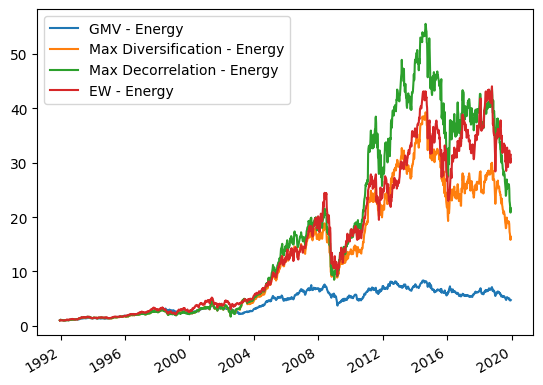

In [55]:
import matplotlib.pyplot as plt

for strat, r in R_OOS.items():
    curve = (1 + r).cumprod()
    plt.plot(curve.index, curve.values, label=f"{strat} - Energy")  # index = DateTimeIndex

plt.legend()
plt.gcf().autofmt_xdate()   
plt.show()

5. **Discussion**

Qualitativement, les courbes semblent cohérentes :

- GMV : courbe beaucoup plus lisse, *drawdowns* plus faibles, mais performance nettement inférieure : c'est ce qui est attendu d’un portefeuille de variance minimale.

- EW / Max Diversification / Max Decorrelation : trajectoires proches et plus volatiles, cohérentes avec l'historique du secteur énergie : boom du pétrole de schiste au début des années 2010, recul par la suite.

Quantitativement, une hausse de x40-x50 entre 1992 et 2014 donne des rendements annualisés autour de 20-22%, éloignés des rendements réels du secteur de l'énergie sur cette période (voir par exemple l'indice [The Energy Select Sector SPDR Fund](https://fr.finance.yahoo.com/quote/XLE/) ).

Comment expliquer cette différence ? En 2014, une équipe de recherche de la *Deutsche Bank* publiait un papier intitulé [*Seven Sins of Quantitative Investing*](https://hudsonthames.org/wp-content/uploads/2022/01/DB-201409-Seven_Sins_of_Quantitative_Investing.pdf). Parmi les sept "péchés" mis en exergue, trois concernent l'analyse précédente :

- biais du survivant : nous ne retenons que les entreprises présentes actuellement dans le S&P500, alors qu'un portefeuille réel aurait intégré des entreprises ayant depuis quitté le S&P500 (du fait de la diminution de leur capitalisation boursière ou de la disparition pure et simple de l'entreprise). Dans le secteur "énergie" ici retenu, le cas d'Enron est le plus notable.
  
- coûts de transaction : le portefeuille est rebalancé toutes les semaines avec les nouveaux poids $w^*$. On fait ici l'hypothèse qu'il n'y a pas de coûts à ce rebalancement, qui grèveraient la performance.

- coûts de la prise de position courte : idem, les portefeuilles ici calculés sont *long-short* et on suppose qu'il est possible et gratuits de prendre des positions courtes.

De plus, on ne prend pas en compte ici le réinvestissement des éventuels dividendes : la performance s'en trouverait alors améliorée et expliquerait les performances faméliques du GMV. On peut ici supposer (sans que nous l'ayons vérifié) que les entreprises du secteur de l'énergie à faible volatilité (donc fortement représentées dans le GMV) sont des *utilities* à faible croissance boursière mais qui versent des dividendes réguliers.
